In [1]:
!pip install networkx

You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
!pip install seaborn

You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [7]:
import networkx as nx

import os
import shutil 
import numpy as np
import pandas as pd
import gc
import json
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from spektral.data import Dataset, Graph, SingleLoader, BatchLoader, DisjointLoader
from spektral.layers import GCNConv
from spektral.layers.convolutional import gcn_conv
from spektral.utils import normalized_adjacency, gcn_filter, degree_matrix
from spektral.models.gcn import GCN 
from spektral.datasets.utils import DATASET_FOLDER

from scipy import sparse
from scipy.special import softmax

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,roc_auc_score,accuracy_score

from keras.callbacks import EarlyStopping, ModelCheckpoint
plt.grid(True)

In [4]:
def plot_graph_dir(G, communities=None):
    pos = nx.spring_layout(G, seed=42)
    
    if communities is not None:
        # Assign colors to nodes based on their communities
        colors = ['white' if community == 0 else 'black' for community in communities]
    else:
        colors = 'black'
    plt.grid(False)
    nx.draw_networkx(G, pos, arrows=True, node_color=colors, edgecolors='black', with_labels=True, font_color="grey")
    plt.show()

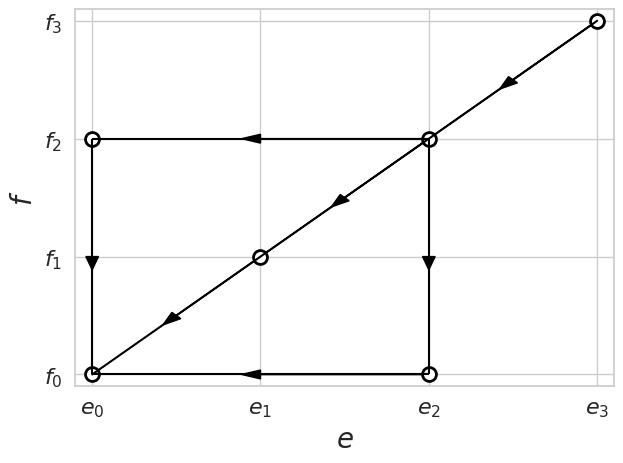

In [93]:
x=[0,1,2,3,0,2]
y=[0,1,2,3,2,0]


plt.plot(x[:4],y[:4], color="black")
plt.vlines(x[2],y[0],y[2], color="black")
plt.vlines(x[0],y[0],y[2], color="black")
plt.hlines(y[2],x[0],x[2], color="black")
plt.hlines(y[0],x[0],x[2], color="black")
plt.arrow(3,3,-2.5,-2.5,ec="black", color="black", head_width=0.075, width=0.001)
plt.arrow(2,2,0,-1,ec="black", color="black", head_width=0.075, width=0.001)
plt.arrow(0,2,0,-1,ec="black", color="black", head_width=0.075, width=0.001)
plt.arrow(2,2,-1,0,ec="black", color="black", head_width=0.075, width=0.001)
plt.arrow(2,0,-1,0,ec="black", color="black", head_width=0.075, width=0.001)
plt.arrow(3,3,-0.5,-0.5,ec="black", color="black", head_width=0.075, width=0.001)
plt.arrow(2,2,-0.5,-0.5,ec="black", color="black", head_width=0.075, width=0.001)
plt.scatter(x,y, color="white", edgecolor="black", s=100, alpha=1, linewidths=2)

plt.gca().set_xlim(-0.1, 3.1)
plt.gca().set_ylim(-0.1, 3.1)
plt.xticks([0,1,2,3], ["$e_0$", "$e_1$", "$e_2$", "$e_3$"], fontsize=16)
plt.yticks([0,1,2,3], ["$f_0$", "$f_1$", "$f_2$", "$f_3$"], fontsize=16)
plt.xlabel("$e$", fontsize=20)
plt.ylabel("$f$", fontsize=20)
#plt.title("Parameter Space", fontsize=16)
plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/parameter_space.eps", format="eps", dpi=1200)
plt.clf()

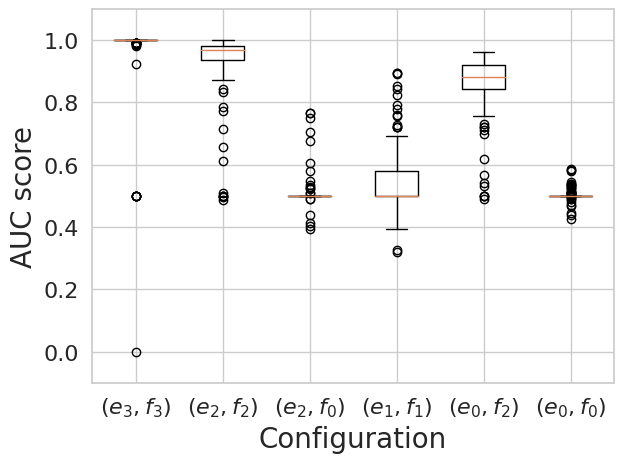

In [95]:
df1 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/A-I/Balanced/NO_flattened/join/join_test.csv")
df2 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-II/Balanced/NO_flattened/join/join_test.csv")
df3 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-IV/Balanced/NO_flattened/join/join_test.csv")
df4 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/C-III/Balanced/NO_flattened/join/join_test.csv")
df5 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-II/Balanced/NO_flattened/join/join_test.csv")
df6 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-IV/Balanced/NO_flattened/join/join_test.csv")

datos1 = np.reshape(np.array(df1.iloc[:,9:10]), -1)
datos2 = np.reshape(np.array(df2.iloc[:,9:10]), -1)
datos3 = np.reshape(np.array(df3.iloc[:,9:10]), -1)
datos4 = np.reshape(np.array(df4.iloc[:,9:10]), -1)
datos5 = np.reshape(np.array(df5.iloc[:,9:10]), -1)
datos6 = np.reshape(np.array(df6.iloc[:,9:10]), -1)

# Graficar los boxplots
plt.boxplot([datos1, datos2, datos3, datos4, datos5, datos6])
plt.grid(True)
# Añadir etiquetas
plt.xticks([1, 2, 3, 4, 5, 6], ["$(e_3,f_3)$", "$(e_2,f_2)$", "$(e_2,f_0)$", "$(e_1,f_1)$", "$(e_0,f_2)$", "$(e_0,f_0)$"], fontsize=16)
plt.yticks(fontsize=16)
plt.gca().set_ylim(-0.1, 1.1)
plt.xlabel('Configuration', fontsize=20)
plt.ylabel('AUC score', fontsize=20)
#plt.title("Balanced Classes", fontsize=16)

plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/balanced_auc.eps", format="eps", dpi=1200)
plt.clf()

In [96]:
datos1 = np.reshape(np.array(df1.iloc[:,7:8]), -1)
datos2 = np.reshape(np.array(df2.iloc[:,7:8]), -1)
datos3 = np.reshape(np.array(df3.iloc[:,7:8]), -1)
datos4 = np.reshape(np.array(df4.iloc[:,7:8]), -1)
datos5 = np.reshape(np.array(df5.iloc[:,7:8]), -1)
datos6 = np.reshape(np.array(df6.iloc[:,7:8]), -1)

# Graficar los boxplots
plt.boxplot([datos1, datos2, datos3, datos4, datos5, datos6])
plt.grid(True)
# Añadir etiquetas
plt.xticks([1, 2, 3, 4, 5, 6], ["$(e_3,f_3)$", "$(e_2,f_2)$", "$(e_2,f_0)$", "$(e_1,f_1)$", "$(e_0,f_2)$", "$(e_0,f_0)$"], fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Configuration", fontsize=20)
plt.ylabel('Specificity', fontsize=20)
plt.gca().set_ylim(-0.1, 1.1)
#plt.title("Balanced Classes", fontsize=16)

plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/balanced_specificity.eps", format="eps", dpi=1200)
plt.clf()

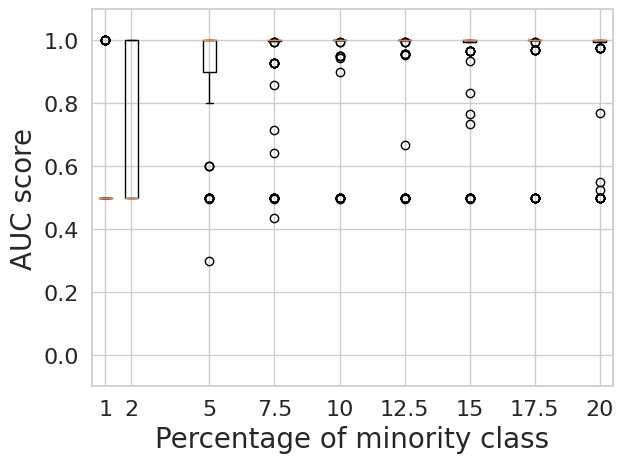

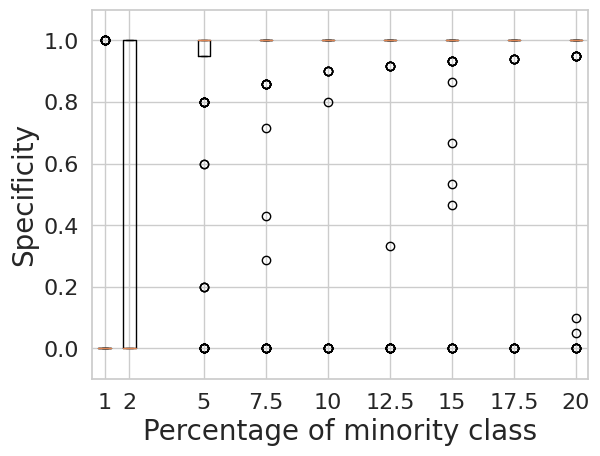

In [98]:
df1 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/A-I/1_percent/NO_flattened/join/join_test.csv")
df2 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/A-I/2_percent/NO_flattened/join/join_test.csv")
df3 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/A-I/5_percent/NO_flattened/join/join_test.csv")
df4 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/A-I/7.5_percent/NO_flattened/join/join_test.csv")
df5 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/A-I/10_percent/NO_flattened/join/join_test.csv")
df6 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/A-I/12.5_percent/NO_flattened/join/join_test.csv")
df7 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/A-I/15_percent/NO_flattened/join/join_test.csv")
df8 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/A-I/17.5_percent/NO_flattened/join/join_test.csv")
df9 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/A-I/20_percent/NO_flattened/join/join_test.csv")

datos1 = np.reshape(np.array(df1.iloc[:,9:10]), -1)
datos2 = np.reshape(np.array(df2.iloc[:,9:10]), -1)
datos3 = np.reshape(np.array(df3.iloc[:,9:10]), -1)
datos4 = np.reshape(np.array(df4.iloc[:,9:10]), -1)
datos5 = np.reshape(np.array(df5.iloc[:,9:10]), -1)
datos6 = np.reshape(np.array(df6.iloc[:,9:10]), -1)
datos7 = np.reshape(np.array(df7.iloc[:,9:10]), -1)
datos8 = np.reshape(np.array(df8.iloc[:,9:10]), -1)
datos9 = np.reshape(np.array(df9.iloc[:,9:10]), -1)


# Graficar los boxplots
positions = [1,2,5,7.5,10,12.5,15,17.5,20]
labels = ["1", "2", "5", "7.5", "10", "12.5", "15", "17.5", "20"]
plt.boxplot([datos1, datos2, datos3, datos4, datos5, datos6, datos7, datos8, datos9], positions=positions, labels=labels)

plt.grid(True)
# Añadir etiquetas
#plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9], ["$1\%$", "$2\%$", "$5\%$", "$7.5\%$", "$10\%$", "$12.5\%$", "$15\%$", "$17.5\%$", "$20\%$"])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().set_ylim(-0.1, 1.1)
plt.xlabel('Percentage of minority class', fontsize=20)
plt.ylabel('AUC score', fontsize=20)
#plt.title("$(e_3,f_3)$ Configuration - Unbalanced Classes", fontsize=16)

plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/e3f3_auc.eps", format="eps", dpi=1200)
plt.clf()

###############################################################

datos1 = np.reshape(np.array(df1.iloc[:,7:8]), -1)
datos2 = np.reshape(np.array(df2.iloc[:,7:8]), -1)
datos3 = np.reshape(np.array(df3.iloc[:,7:8]), -1)
datos4 = np.reshape(np.array(df4.iloc[:,7:8]), -1)
datos5 = np.reshape(np.array(df5.iloc[:,7:8]), -1)
datos6 = np.reshape(np.array(df6.iloc[:,7:8]), -1)
datos7 = np.reshape(np.array(df7.iloc[:,7:8]), -1)
datos8 = np.reshape(np.array(df8.iloc[:,7:8]), -1)
datos9 = np.reshape(np.array(df9.iloc[:,7:8]), -1)

# Graficar los boxplots
positions = [1,2,5,7.5,10,12.5,15,17.5,20]
labels = ["1", "2", "5", "7.5", "10", "12.5", "15", "17.5", "20"]
plt.boxplot([datos1, datos2, datos3, datos4, datos5, datos6, datos7, datos8, datos9], positions=positions, labels=labels)

plt.grid(True)
# Añadir etiquetas
#plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9], ["$1\%$", "$2\%$", "$5\%$", "$7.5\%$", "$10\%$", "$12.5\%$", "$15\%$", "$17.5\%$", "$20\%$"])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().set_ylim(-0.1, 1.1)
plt.xlabel('Percentage of minority class', fontsize=20)
plt.ylabel('Specificity', fontsize=20)
#plt.title("$(e_3,f_3)$ Configuration - Unbalanced Classes", fontsize=16)

plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/e3f3_specificity.eps", format="eps", dpi=1200)
plt.clf()

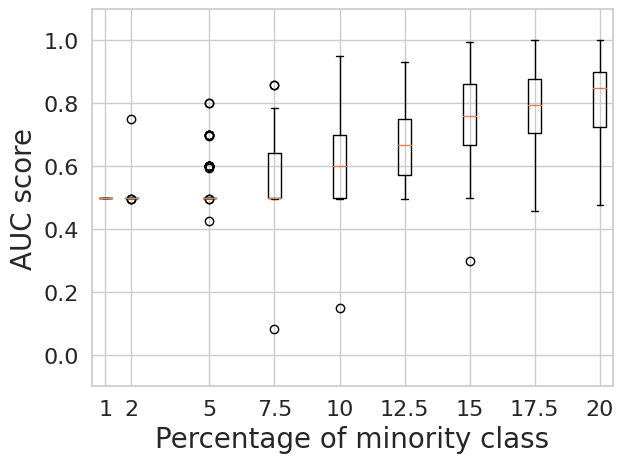

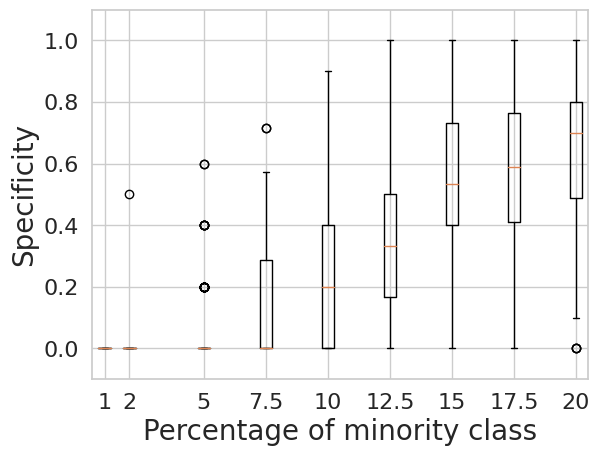

In [100]:
df1 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-II/1_percent/NO_flattened/join/join_test.csv")
df2 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-II/2_percent/NO_flattened/join/join_test.csv")
df3 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-II/5_percent/NO_flattened/join/join_test.csv")
df4 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-II/7.5_percent/NO_flattened/join/join_test.csv")
df5 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-II/10_percent/NO_flattened/join/join_test.csv")
df6 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-II/12.5_percent/NO_flattened/join/join_test.csv")
df7 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-II/15_percent/NO_flattened/join/join_test.csv")
df8 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-II/17.5_percent/NO_flattened/join/join_test.csv")
df9 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-II/20_percent/NO_flattened/join/join_test.csv")

datos1 = np.reshape(np.array(df1.iloc[:,9:10]), -1)
datos2 = np.reshape(np.array(df2.iloc[:,9:10]), -1)
datos3 = np.reshape(np.array(df3.iloc[:,9:10]), -1)
datos4 = np.reshape(np.array(df4.iloc[:,9:10]), -1)
datos5 = np.reshape(np.array(df5.iloc[:,9:10]), -1)
datos6 = np.reshape(np.array(df6.iloc[:,9:10]), -1)
datos7 = np.reshape(np.array(df7.iloc[:,9:10]), -1)
datos8 = np.reshape(np.array(df8.iloc[:,9:10]), -1)
datos9 = np.reshape(np.array(df9.iloc[:,9:10]), -1)

# Graficar los boxplots
positions = [1,2,5,7.5,10,12.5,15,17.5,20]
labels = ["1", "2", "5", "7.5", "10", "12.5", "15", "17.5", "20"]
plt.boxplot([datos1, datos2, datos3, datos4, datos5, datos6, datos7, datos8, datos9], positions=positions, labels=labels)
plt.grid(True)

# Añadir etiquetas
#plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9], ["$1\%$", "$2\%$", "$5\%$", "$7.5\%$", "$10\%$", "$12.5\%$", "$15\%$", "$17.5\%$", "$20\%$"])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Percentage of minority class',fontsize=20)
plt.ylabel('AUC score',fontsize=20)
plt.gca().set_ylim(-0.1, 1.1)
#plt.title("$(e_2,f_2)$ Configuration - Unbalanced Classes",fontsize=16)

plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/e2f2_auc.eps", format="eps", dpi=1200)
plt.clf()

###############################################################

datos1 = np.reshape(np.array(df1.iloc[:,7:8]), -1)
datos2 = np.reshape(np.array(df2.iloc[:,7:8]), -1)
datos3 = np.reshape(np.array(df3.iloc[:,7:8]), -1)
datos4 = np.reshape(np.array(df4.iloc[:,7:8]), -1)
datos5 = np.reshape(np.array(df5.iloc[:,7:8]), -1)
datos6 = np.reshape(np.array(df6.iloc[:,7:8]), -1)
datos7 = np.reshape(np.array(df7.iloc[:,7:8]), -1)
datos8 = np.reshape(np.array(df8.iloc[:,7:8]), -1)
datos9 = np.reshape(np.array(df9.iloc[:,7:8]), -1)

# Graficar los boxplots
positions = [1,2,5,7.5,10,12.5,15,17.5,20]
labels = ["1", "2", "5", "7.5", "10", "12.5", "15", "17.5", "20"]
plt.boxplot([datos1, datos2, datos3, datos4, datos5, datos6, datos7, datos8, datos9], positions=positions, labels=labels)

plt.grid(True)
# Añadir etiquetas
#plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9], ["$1\%$", "$2\%$", "$5\%$", "$7.5\%$", "$10\%$", "$12.5\%$", "$15\%$", "$17.5\%$", "$20\%$"])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().set_ylim(-0.1, 1.1)
plt.xlabel('Percentage of minority class', fontsize=20)
plt.ylabel('Specificity', fontsize=20)
#plt.title("$(e_2,f_2)$ Configuration - Unbalanced Classes", fontsize=16)

plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/e2f2_specificity.eps", format="eps", dpi=1200)
plt.clf()

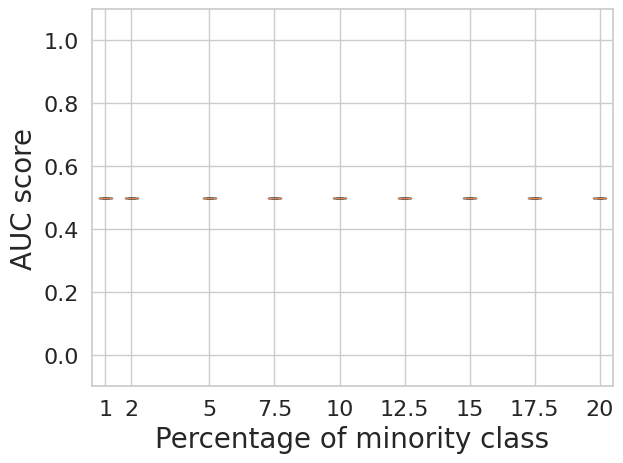

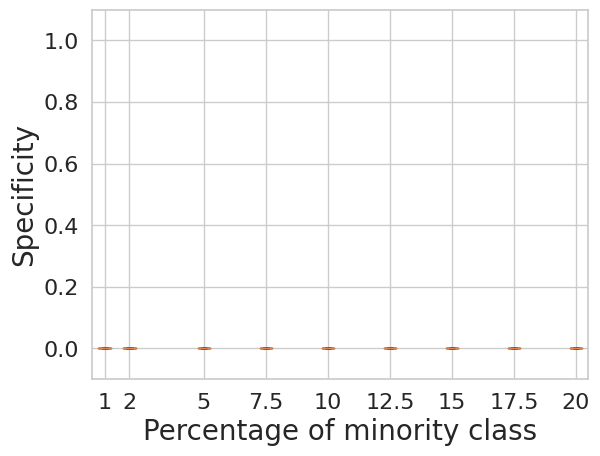

In [102]:
df1 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-IV/1_percent/NO_flattened/join/join_test.csv")
df2 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-IV/2_percent/NO_flattened/join/join_test.csv")
df3 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-IV/5_percent/NO_flattened/join/join_test.csv")
df4 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-IV/7.5_percent/NO_flattened/join/join_test.csv")
df5 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-IV/10_percent/NO_flattened/join/join_test.csv")
df6 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-IV/12.5_percent/NO_flattened/join/join_test.csv")
df7 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-IV/15_percent/NO_flattened/join/join_test.csv")
df8 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-IV/17.5_percent/NO_flattened/join/join_test.csv")
df9 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/B-IV/20_percent/NO_flattened/join/join_test.csv")

datos1 = np.reshape(np.array(df1.iloc[:,9:10]), -1)
datos2 = np.reshape(np.array(df2.iloc[:,9:10]), -1)
datos3 = np.reshape(np.array(df3.iloc[:,9:10]), -1)
datos4 = np.reshape(np.array(df4.iloc[:,9:10]), -1)
datos5 = np.reshape(np.array(df5.iloc[:,9:10]), -1)
datos6 = np.reshape(np.array(df6.iloc[:,9:10]), -1)
datos7 = np.reshape(np.array(df7.iloc[:,9:10]), -1)
datos8 = np.reshape(np.array(df8.iloc[:,9:10]), -1)
datos9 = np.reshape(np.array(df9.iloc[:,9:10]), -1)

# Graficar los boxplots
positions = [1,2,5,7.5,10,12.5,15,17.5,20]
labels = ["1", "2", "5", "7.5", "10", "12.5", "15", "17.5", "20"]
plt.boxplot([datos1, datos2, datos3, datos4, datos5, datos6, datos7, datos8, datos9], positions=positions, labels=labels)
plt.grid(True)

# Añadir etiquetas
#plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9], ["$1\%$", "$2\%$", "$5\%$", "$7.5\%$", "$10\%$", "$12.5\%$", "$15\%$", "$17.5\%$", "$20\%$"])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Percentage of minority class', fontsize=20)
plt.ylabel('AUC score', fontsize=20)
plt.gca().set_ylim(-0.1, 1.1)
#plt.title("$(e_2,f_0)$ Configuration - Unbalanced Classes", fontsize=16)

plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/e2f0_auc.eps", format="eps", dpi=1200)
plt.clf()

###############################################################

datos1 = np.reshape(np.array(df1.iloc[:,7:8]), -1)
datos2 = np.reshape(np.array(df2.iloc[:,7:8]), -1)
datos3 = np.reshape(np.array(df3.iloc[:,7:8]), -1)
datos4 = np.reshape(np.array(df4.iloc[:,7:8]), -1)
datos5 = np.reshape(np.array(df5.iloc[:,7:8]), -1)
datos6 = np.reshape(np.array(df6.iloc[:,7:8]), -1)
datos7 = np.reshape(np.array(df7.iloc[:,7:8]), -1)
datos8 = np.reshape(np.array(df8.iloc[:,7:8]), -1)
datos9 = np.reshape(np.array(df9.iloc[:,7:8]), -1)

# Graficar los boxplots
positions = [1,2,5,7.5,10,12.5,15,17.5,20]
labels = ["1", "2", "5", "7.5", "10", "12.5", "15", "17.5", "20"]
plt.boxplot([datos1, datos2, datos3, datos4, datos5, datos6, datos7, datos8, datos9], positions=positions, labels=labels)

plt.grid(True)
# Añadir etiquetas
#plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9], ["$1\%$", "$2\%$", "$5\%$", "$7.5\%$", "$10\%$", "$12.5\%$", "$15\%$", "$17.5\%$", "$20\%$"])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().set_ylim(-0.1, 1.1)
plt.xlabel('Percentage of minority class', fontsize=20)
plt.ylabel('Specificity', fontsize=20)
#plt.title("$(e_2,f_0)$ Configuration - Unbalanced Classes", fontsize=16)

plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/e2f0_specificity.eps", format="eps", dpi=1200)
plt.clf()

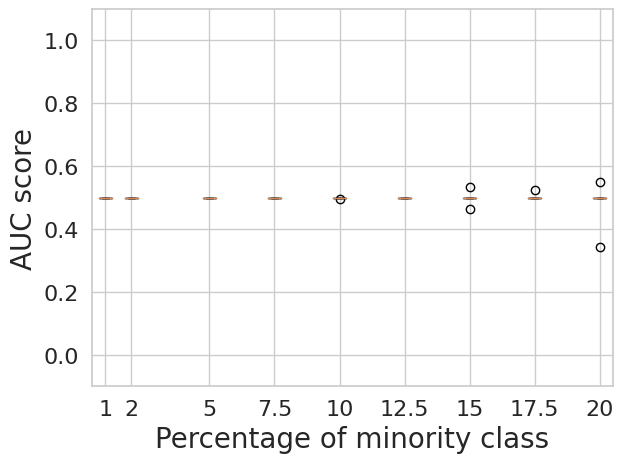

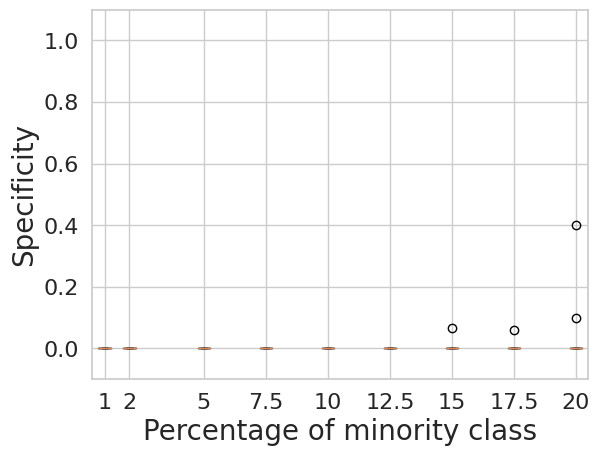

In [104]:
df1 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/C-III/1_percent/NO_flattened/join/join_test.csv")
df2 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/C-III/2_percent/NO_flattened/join/join_test.csv")
df3 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/C-III/5_percent/NO_flattened/join/join_test.csv")
df4 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/C-III/7.5_percent/NO_flattened/join/join_test.csv")
df5 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/C-III/10_percent/NO_flattened/join/join_test.csv")
df6 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/C-III/12.5_percent/NO_flattened/join/join_test.csv")
df7 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/C-III/15_percent/NO_flattened/join/join_test.csv")
df8 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/C-III/17.5_percent/NO_flattened/join/join_test.csv")
df9 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/C-III/20_percent/NO_flattened/join/join_test.csv")

datos1 = np.reshape(np.array(df1.iloc[:,9:10]), -1)
datos2 = np.reshape(np.array(df2.iloc[:,9:10]), -1)
datos3 = np.reshape(np.array(df3.iloc[:,9:10]), -1)
datos4 = np.reshape(np.array(df4.iloc[:,9:10]), -1)
datos5 = np.reshape(np.array(df5.iloc[:,9:10]), -1)
datos6 = np.reshape(np.array(df6.iloc[:,9:10]), -1)
datos7 = np.reshape(np.array(df7.iloc[:,9:10]), -1)
datos8 = np.reshape(np.array(df8.iloc[:,9:10]), -1)
datos9 = np.reshape(np.array(df9.iloc[:,9:10]), -1)

# Graficar los boxplots
positions = [1,2,5,7.5,10,12.5,15,17.5,20]
labels = ["1", "2", "5", "7.5", "10", "12.5", "15", "17.5", "20"]
plt.boxplot([datos1, datos2, datos3, datos4, datos5, datos6, datos7, datos8, datos9], positions=positions, labels=labels)
plt.grid(True)

# Añadir etiquetas
#plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9], ["$1\%$", "$2\%$", "$5\%$", "$7.5\%$", "$10\%$", "$12.5\%$", "$15\%$", "$17.5\%$", "$20\%$"])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Percentage of minority class',fontsize=20)
plt.ylabel('AUC score',fontsize=20)
plt.gca().set_ylim(-0.1, 1.1)
#plt.title("$(e_1,f_1)$ Configuration - Unbalanced Classes",fontsize=16)

plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/e1f1_auc.eps", format="eps", dpi=1200)
plt.clf()

###############################################################

datos1 = np.reshape(np.array(df1.iloc[:,7:8]), -1)
datos2 = np.reshape(np.array(df2.iloc[:,7:8]), -1)
datos3 = np.reshape(np.array(df3.iloc[:,7:8]), -1)
datos4 = np.reshape(np.array(df4.iloc[:,7:8]), -1)
datos5 = np.reshape(np.array(df5.iloc[:,7:8]), -1)
datos6 = np.reshape(np.array(df6.iloc[:,7:8]), -1)
datos7 = np.reshape(np.array(df7.iloc[:,7:8]), -1)
datos8 = np.reshape(np.array(df8.iloc[:,7:8]), -1)
datos9 = np.reshape(np.array(df9.iloc[:,7:8]), -1)

# Graficar los boxplots
positions = [1,2,5,7.5,10,12.5,15,17.5,20]
labels = ["1", "2", "5", "7.5", "10", "12.5", "15", "17.5", "20"]
plt.boxplot([datos1, datos2, datos3, datos4, datos5, datos6, datos7, datos8, datos9], positions=positions, labels=labels)

plt.grid(True)
# Añadir etiquetas
#plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9], ["$1\%$", "$2\%$", "$5\%$", "$7.5\%$", "$10\%$", "$12.5\%$", "$15\%$", "$17.5\%$", "$20\%$"])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().set_ylim(-0.1, 1.1)
plt.xlabel('Percentage of minority class', fontsize=20)
plt.ylabel('Specificity', fontsize=20)
#plt.title("$(e_1,f_1)$ Configuration - Unbalanced Classes", fontsize=16)

plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/e1f1_specificity.eps", format="eps", dpi=1200)
plt.clf()

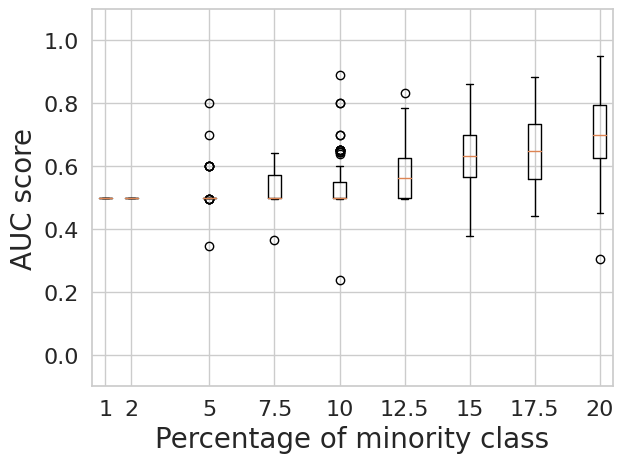

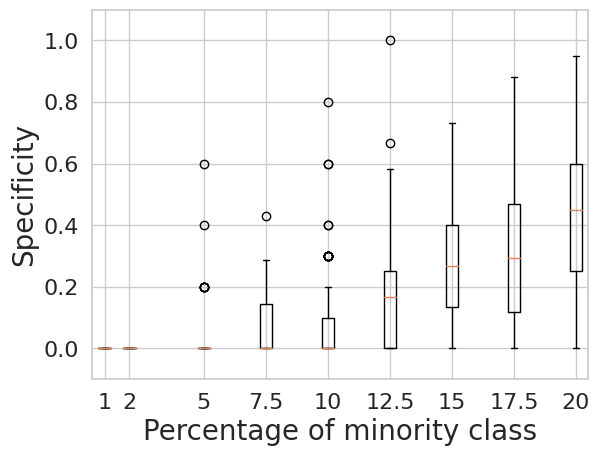

In [106]:
df1 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-II/1_percent/NO_flattened/join/join_test.csv")
df2 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-II/2_percent/NO_flattened/join/join_test.csv")
df3 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-II/5_percent/NO_flattened/join/join_test.csv")
df4 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-II/7.5_percent/NO_flattened/join/join_test.csv")
df5 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-II/10_percent/NO_flattened/join/join_test.csv")
df6 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-II/12.5_percent/NO_flattened/join/join_test.csv")
df7 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-II/15_percent/NO_flattened/join/join_test.csv")
df8 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-II/17.5_percent/NO_flattened/join/join_test.csv")
df9 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-II/20_percent/NO_flattened/join/join_test.csv")

datos1 = np.reshape(np.array(df1.iloc[:,9:10]), -1)
datos2 = np.reshape(np.array(df2.iloc[:,9:10]), -1)
datos3 = np.reshape(np.array(df3.iloc[:,9:10]), -1)
datos4 = np.reshape(np.array(df4.iloc[:,9:10]), -1)
datos5 = np.reshape(np.array(df5.iloc[:,9:10]), -1)
datos6 = np.reshape(np.array(df6.iloc[:,9:10]), -1)
datos7 = np.reshape(np.array(df7.iloc[:,9:10]), -1)
datos8 = np.reshape(np.array(df8.iloc[:,9:10]), -1)
datos9 = np.reshape(np.array(df9.iloc[:,9:10]), -1)

# Graficar los boxplots
positions = [1,2,5,7.5,10,12.5,15,17.5,20]
labels = ["1", "2", "5", "7.5", "10", "12.5", "15", "17.5", "20"]
plt.boxplot([datos1, datos2, datos3, datos4, datos5, datos6, datos7, datos8, datos9], positions=positions, labels=labels)
plt.grid(True)

# Añadir etiquetas
#plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9], ["$1\%$", "$2\%$", "$5\%$", "$7.5\%$", "$10\%$", "$12.5\%$", "$15\%$", "$17.5\%$", "$20\%$"])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Percentage of minority class',fontsize=20)
plt.ylabel('AUC score',fontsize=20)
plt.gca().set_ylim(-0.1, 1.1)
#plt.title("$(e_0,f_2)$ Configuration - Unbalanced Classes",fontsize=16)

plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/e0f2_auc.eps", format="eps", dpi=1200)
plt.clf()

###############################################################

datos1 = np.reshape(np.array(df1.iloc[:,7:8]), -1)
datos2 = np.reshape(np.array(df2.iloc[:,7:8]), -1)
datos3 = np.reshape(np.array(df3.iloc[:,7:8]), -1)
datos4 = np.reshape(np.array(df4.iloc[:,7:8]), -1)
datos5 = np.reshape(np.array(df5.iloc[:,7:8]), -1)
datos6 = np.reshape(np.array(df6.iloc[:,7:8]), -1)
datos7 = np.reshape(np.array(df7.iloc[:,7:8]), -1)
datos8 = np.reshape(np.array(df8.iloc[:,7:8]), -1)
datos9 = np.reshape(np.array(df9.iloc[:,7:8]), -1)

# Graficar los boxplots
positions = [1,2,5,7.5,10,12.5,15,17.5,20]
labels = ["1", "2", "5", "7.5", "10", "12.5", "15", "17.5", "20"]
plt.boxplot([datos1, datos2, datos3, datos4, datos5, datos6, datos7, datos8, datos9], positions=positions, labels=labels)

plt.grid(True)
# Añadir etiquetas
#plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9], ["$1\%$", "$2\%$", "$5\%$", "$7.5\%$", "$10\%$", "$12.5\%$", "$15\%$", "$17.5\%$", "$20\%$"])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().set_ylim(-0.1, 1.1)
plt.xlabel('Percentage of minority class', fontsize=20)
plt.ylabel('Specificity', fontsize=20)
#plt.title("$(e_0,f_2)$ Configuration - Unbalanced Classes", fontsize=16)

plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/e0f2_specificity.eps", format="eps", dpi=1200)
plt.clf()

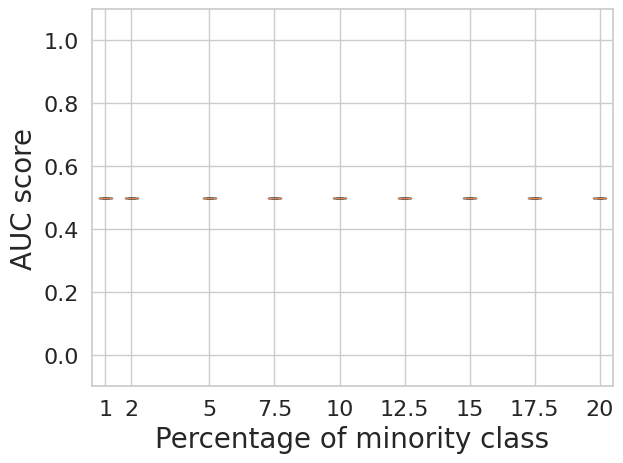

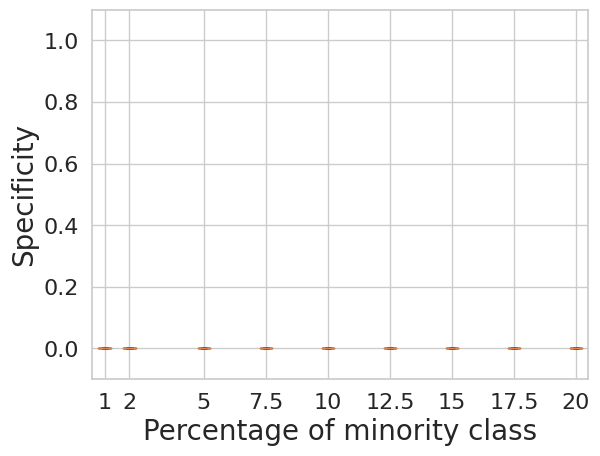

In [108]:
df1 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-IV/1_percent/NO_flattened/join/join_test.csv")
df2 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-IV/2_percent/NO_flattened/join/join_test.csv")
df3 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-IV/5_percent/NO_flattened/join/join_test.csv")
df4 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-IV/7.5_percent/NO_flattened/join/join_test.csv")
df5 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-IV/10_percent/NO_flattened/join/join_test.csv")
df6 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-IV/12.5_percent/NO_flattened/join/join_test.csv")
df7 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-IV/15_percent/NO_flattened/join/join_test.csv")
df8 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-IV/17.5_percent/NO_flattened/join/join_test.csv")
df9 = pd.read_csv("/mnt/synthetic/resultados/CacicSpringer2023/D-IV/20_percent/NO_flattened/join/join_test.csv")

datos1 = np.reshape(np.array(df1.iloc[:,9:10]), -1)
datos2 = np.reshape(np.array(df2.iloc[:,9:10]), -1)
datos3 = np.reshape(np.array(df3.iloc[:,9:10]), -1)
datos4 = np.reshape(np.array(df4.iloc[:,9:10]), -1)
datos5 = np.reshape(np.array(df5.iloc[:,9:10]), -1)
datos6 = np.reshape(np.array(df6.iloc[:,9:10]), -1)
datos7 = np.reshape(np.array(df7.iloc[:,9:10]), -1)
datos8 = np.reshape(np.array(df8.iloc[:,9:10]), -1)
datos9 = np.reshape(np.array(df9.iloc[:,9:10]), -1)

# Graficar los boxplots
positions = [1,2,5,7.5,10,12.5,15,17.5,20]
labels = ["1", "2", "5", "7.5", "10", "12.5", "15", "17.5", "20"]
plt.boxplot([datos1, datos2, datos3, datos4, datos5, datos6, datos7, datos8, datos9], positions=positions, labels=labels)
plt.grid(True)
# Añadir etiquetas
#plt.xticks([1,2,5,7.5,10,12.5,15,17.5,20])#, [1,2,5,7.5,10,12.5,15,17.5,20])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel('Percentage of minority class',fontsize=20)
plt.ylabel('AUC score',fontsize=20)
plt.gca().set_ylim(-0.1, 1.1)
#plt.title("$(e_0,f_0)$ Configuration - Unbalanced Classes",fontsize=16)

plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/e0f0_auc.eps", format="eps", dpi=1200)
plt.clf()

###############################################################

datos1 = np.reshape(np.array(df1.iloc[:,7:8]), -1)
datos2 = np.reshape(np.array(df2.iloc[:,7:8]), -1)
datos3 = np.reshape(np.array(df3.iloc[:,7:8]), -1)
datos4 = np.reshape(np.array(df4.iloc[:,7:8]), -1)
datos5 = np.reshape(np.array(df5.iloc[:,7:8]), -1)
datos6 = np.reshape(np.array(df6.iloc[:,7:8]), -1)
datos7 = np.reshape(np.array(df7.iloc[:,7:8]), -1)
datos8 = np.reshape(np.array(df8.iloc[:,7:8]), -1)
datos9 = np.reshape(np.array(df9.iloc[:,7:8]), -1)

# Graficar los boxplots
positions = [1,2,5,7.5,10,12.5,15,17.5,20]
labels = ["1", "2", "5", "7.5", "10", "12.5", "15", "17.5", "20"]
plt.boxplot([datos1, datos2, datos3, datos4, datos5, datos6, datos7, datos8, datos9], positions=positions, labels=labels)

plt.grid(True)
# Añadir etiquetas
#plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9], ["$1\%$", "$2\%$", "$5\%$", "$7.5\%$", "$10\%$", "$12.5\%$", "$15\%$", "$17.5\%$", "$20\%$"])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.gca().set_ylim(-0.1, 1.1)
plt.xlabel('Percentage of minority class', fontsize=20)
plt.ylabel('Specificity', fontsize=20)
#plt.title("$(e_0,f_0)$ Configuration - Unbalanced Classes", fontsize=16)

plt.show()
plt.tight_layout()
#plt.savefig("/mnt/synthetic/resultados/CacicSpringer2023/images/e0f0_specificity.eps", format="eps", dpi=1200)
plt.clf()